In [1]:
import numpy as np
from matplotlib.pyplot import*
from scipy import stats as st
from scipy import optimize as op
from scipy import fftpack
from scipy import signal
from scipy.special import erf,erfc
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.collections import PolyCollection
from scipy.integrate import *
%matplotlib inline  

# Expérience 1: Temperature initiale uniforme + mu/c/kapa tilde = 1

In [47]:
deltax=1e-2 
deltat=.5*deltax**2

d=1. # durée de l'évolution

Nx=int(1/deltax) # nombre d'intervalles sur l'axe spatial
Nt=int(d/deltat) # nombre d'intervalles de temps
x=np.linspace(0,1,Nx+1) 
t=np.linspace(0,d,Nt+1)

theta=np.zeros((Nx+1,Nt+1)) #initialisation du champ de temperature : premier indice (espace) et second (temps)

# valeur de mu,c,kapa tilde (liste de 1 dans ce premier cas)
mu=[1 for i in range(Nx)]
c=[1 for i in range(Nx)]
kapa=[1 for i in range(Nx+1)]
jth=[0 for i in range (Nx)]


#condition initiale :
for i in range(Nx):
    theta[i,0]=0

# conditions aux limites :
for j in range(Nt):
    theta[0,j]=0
    theta[Nx,j]=1
       
for j in range(Nt):
    for i in range (1,Nx): 
        theta[i,j+1]=(1/(c[i]*mu[i]))*(deltat/deltax)*(kapa[i+1]*((theta[i+1,j]-theta[i,j])/deltax)-kapa[i]
                                                       *(theta[i,j]-theta[i-1,j])/deltax)+theta[i,j] 
    

# Visualisation des courbes


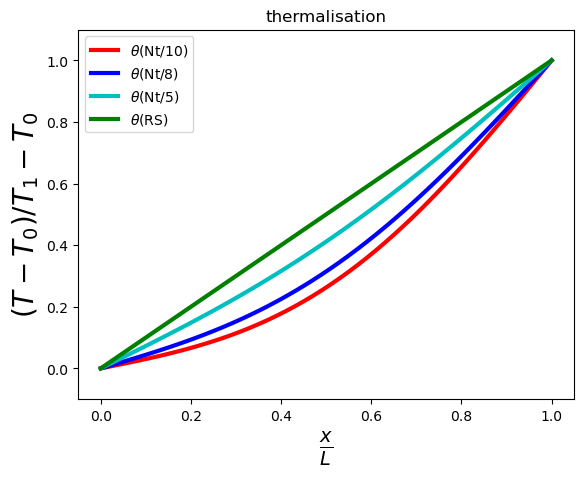

In [48]:

N_visu=Nt//10#indice de l'instant auquel on veut visualiser le champ de température
plot(x,theta[:,N_visu],'r-',linewidth=3,label='$\\theta$(Nt/10)') #visualisation du champ de température
plot(x,theta[:,Nt//8],'b-',linewidth=3,label='$\\theta$(Nt/8)')
plot(x,theta[:,Nt//5],'c-',linewidth=3,label='$\\theta$(Nt/5)')
plot(x,theta[:,Nt-1],'g-',linewidth=3,label='$\\theta$(RS)')
#plot(x,T[:,0],'r--',linewidth=1,label='$\\theta$ à $t=0$') #visualisation du champ de température initial




legend(loc=2)
ylim([-.1,1.1])
#axhline(0,ls='--',lw=2)
xlabel("$\\frac{x}{L}$",size=20);ylabel("$(T-T_0)/T_1-T_0$",size=20);title("thermalisation")
savefig("1D 1 seul matériau")

On a tracé ici dans le cas où kapa est une constante la température adimenssionée (T_tilde) en fonction de la longuer adimensionée $(x/L)$. On a repésenté plusieurs courbes en qui représentes des instants différents :la coure rouge est l'instant le plus tôt et la courbe verte pour une durée plus longue qui repésente donc le régime stationaire. 
Dans le cas du régime stationaire on retrouve bien une droite qui correpsond à la tempérautre que l'on sait calculer théoriquement : $T(x)=(T2-T1)x/L + T1$

# Expérience : Temperature initiale uniforme + mu/c/kapa tilde prennent deux valeurs (2 matériaux à la suite) 

In [53]:
deltax=1e-2 
deltat=.5*deltax**2

d=1. # durée de l'évolution


Nx=int(1/deltax) # nombre d'intervalles sur l'axe spatial
print(Nx)
Nt=int(d/deltat) # nombre d'intervalles de temps
x=np.linspace(0,1,Nx+1) 
t=np.linspace(0,d,Nt+1)

theta=np.zeros((Nx+1,Nt+1)) #initialisation du champ de temperature : premier indice (espace) et second (temps)

# valeur de mu,c,kapa tilde
L1=[1 for i in range(Nx//3)]
L2=[0.067 for i in range(Nx//3)]
L3=[1 for i in range(Nx//3+2)]
kapa=L1+L2+L3
print(len(kapa))
mu=[1 for i in range(Nx+1)]
c=[1 for i in range(Nx+1)]


#condition initiale :
for i in range(Nx):
    theta[i,0]=0

#conditions aux limites
for j in range(Nt):
    theta[0,j]=0
    theta[Nx,j]=1
    
# calcul du champ de température 
for j in range(Nt):
    for i in range (1,Nx): 
        theta[i,j+1]=(1/(c[i]*mu[i]))*(deltat/deltax)*(kapa[i+1]*((theta[i+1,j]-theta[i,j])/deltax)-kapa[i]
                                                       *(theta[i,j]-theta[i-1,j])/deltax)+theta[i,j] 
    

    

100
101


# Visualisation des courbes


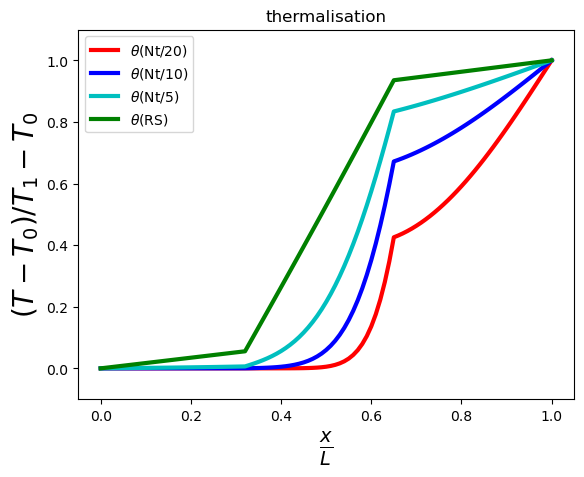

In [54]:
N_visu=Nt//20#indice de l'instant auquel on veut visualiser le champ de température
plot(x,theta[:,N_visu],'r-',linewidth=3,label='$\\theta$(Nt/20)') #visualisation du champ de température
plot(x,theta[:,Nt//10],'b-',linewidth=3,label='$\\theta$(Nt/10)')
plot(x,theta[:,Nt//5],'c-',linewidth=3,label='$\\theta$(Nt/5)')
plot(x,theta[:,Nt-1],'g-',linewidth=3,label='$\\theta$(RS)')
legend(loc=2)
ylim([-.1,1.1])
xlabel("$\\frac{x}{L}$",size=20);ylabel("$(T-T_0)/T_1-T_0$",size=20);title("thermalisation")
savefig("1D barre d'air")

On a modélise ici deux matériaux de longueur $L/2$ à la suite (en série) de valeurs de kapa_tilde successivement 1 et 0.5. 
On retouve bien en régime stationaire (courbe verte) deux droites de pentes différentes qui représente la température qui est linéaire dans les deux matériaux. Le point de cassure/jonction est bien en $L/2$ et on a bien la continuité de la température. 
Cela corespond bien à l'étude théorique que l'on réalise (exo 24.2 livre physique): 

$T(x)=A_1x+B_1$ si $x	\in [0,L/2]$

$T(x)=A_2x+B_2$ si $x	\in [L/2,L]$

Conditions aux limites: 

$T(0)=T_1=B_1$ 

$T(L)=T_2A_2L+B_2$

Continuité de jth en $x=L/2$ : 

$k_1A_1=k_2A_2$

Continuité de la température en $L/S$:

$A_1L/2+B_1=A_2L/2+B_2$

Nous avons 4 équations pour 4 inconus et l'on trouve finalement : 

$A_1=\frac{2k_2(T_2-T_1)}{L(k_1+k_2)}$

$A_2=\frac{2k_1(T_2-T_1)}{L(k_1+k_2)}$

$B_1=T_1$

$B_2=T_2-\frac{2k_1(T_2-T_1)}{L(k_1+k_2)}$

# Expéreince 3 : Calcul de la resistance equivalente (Meme conditions que exp 2) 

In [60]:
kc=0.37
L=3e-3
# calcul du jth(adimensionné)en RS : (sous forme d'un tableau pour cahque valeur en fonction des x)
j=[0 for i in range (Nx)]
for i in range(Nx):
    j[i]= -kapa[i]*(theta[i+1,Nt-1]-theta[i,Nt-1])/deltax
# en RS jth est constant (on prends quand même une valeur moyenne)
somme=0
for i in range(len(j)):
    somme=somme+j[i]
jmoy=somme/len(j)

# calcul de la résistance thermique (non adimensionnée)
Req=-L/(kc*jmoy)
print("Req =",Req)

#resistance 1 :

R1=(L/3)/(kc)
R2=(L/3)/(kc*0.067)
R3=(L/3)/(kc)
Req_theorie = R1+R2+R3
print("Req_theorie =",Req_theorie)

Req = 0.04024747439475338
Req_theorie = 0.04574425171440097


In [10]:
#valeur des cstes du problème
k0=0.23
L=5*1e-3
S=2.5*1e-3

#calcul de R1 (longueur de L/2 et kapa_tilde = 1)
R1=(L/3)/(1*S)
R3=R1
#calcul de R2 (longueur de L/2 et kapa_tilde = 0.5)
R2=(L/3)/(0.3*S)

# calcul de kapa_tilde*deltaT_tilde/delatX = jth adimensionné 
j=[0 for i in range (Nx)]
for i in range(Nx):
    j[i]= -kapa[i]*(theta[i+1,Nt-1]-theta[i,Nt-1])/deltax

# en régime staitonaire comme div(jth)=0 le flux est conservatif. Le flux à travers une surface est independant
#de la surface choisie jth est aussi constant
#calculons donc une moyenne des valuers de J
somme=0
for i in range(len(j)):
    somme=somme+j[i]
jmoy=somme/len(j)
print("jmoy =",jmoy)
#calcul de Req(longeur L/2 du matériau kapa_tilde1 et L/2 du matériau kapa_tilde2)
Req= -L/(S*jmoy)
R=(theta[0,Nt-1]-theta[Nx,Nt-1])/(jmoy*S)

#calcul du flux thermique adimensionné qui traverse les matérieux 

flux_ad=(theta[0,Nt-1]-theta[Nx,Nt-1])/Req


#comparaison de Req et R1 + R2
print("R1+R2+R3 =",R1+R2+R3)
print("Req =",Req)
print(R)
print("flux adimensionné =" ,flux_ad)

jmoy = -1.0000000000000007
R1+R2+R3 = 3.5555555555555562
Req = 1.9999999999999987
399.9999999999997
flux adimensionné = -0.5000000000000003


(-1.0, 0.0)

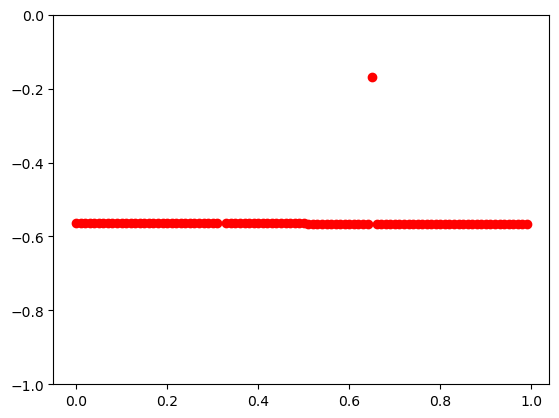

In [139]:
plot(x[:-1],J,'ro')
ylim([-1,0])

Dans cette partie nous avons vérifié qu'en mettant deux matériaux à la suite (en série), en régime stationaire la résistance équivalente est bien égale à la somme des resisantance des deux matériaux. 

faire la demo du calcul à la main 

mettre cete expérience en parallèle avec le DM sur la plongée : 3 résisstances à la suite et analogie avec un système électrique pour prévoir la durée avant l'hypothermie 

# condition aux limites de type conducto convectif (eau) et thermostat (peau)